In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Dataset/bank-full.csv',sep=';')
#df_numerica = df[['age','balance','duration','y']]
df_numerica = df[['age','job','balance','duration','campaign','pdays','previous','default','housing','loan','y']]
#df_binaria = df[['default','housing','loan','y']]

In [80]:
df_numerica.columns
df_numerica.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       45211 non-null  int64 
 1   job       45211 non-null  object
 2   balance   45211 non-null  int64 
 3   duration  45211 non-null  int64 
 4   campaign  45211 non-null  int64 
 5   pdays     45211 non-null  int64 
 6   previous  45211 non-null  int64 
 7   default   45211 non-null  object
 8   housing   45211 non-null  object
 9   loan      45211 non-null  object
 10  y         45211 non-null  object
dtypes: int64(6), object(5)
memory usage: 3.8+ MB


In [86]:
mapeamento = {'yes':1,'no':0}
df_numerica = df_numerica.replace(mapeamento)
df = df.replace(mapeamento)

map_job = {"admin.":0,"unknown":1,"unemployed":2,"management":3,"housemaid":4,"entrepreneur":5,"student":6,
"blue-collar":7,"self-employed":8,"retired":9,"technician":10,"services":11}
df_numerica = df_numerica.replace(map_job)

display(df_numerica.head(10))

Y = df_numerica['y']
X = df_numerica.drop(columns=['y'])

#Y = df['y']
#X = df.drop(columns=['y'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

,age,job,balance,duration,campaign,pdays,previous,default,housing,loan,y
0,58,3,2143,261,1,-1,0,0,1,0,0
1,44,10,29,151,1,-1,0,0,1,0,0
2,33,5,2,76,1,-1,0,0,1,1,0
3,47,7,1506,92,1,-1,0,0,1,0,0
4,33,1,1,198,1,-1,0,0,0,0,0
5,35,3,231,139,1,-1,0,0,1,0,0
6,28,3,447,217,1,-1,0,0,1,1,0
7,42,5,2,380,1,-1,0,1,1,0,0
8,58,9,121,50,1,-1,0,0,1,0,0
9,43,10,593,55,1,-1,0,0,1,0,0


A acurácia do modelo Random Forest foi de 89.25%


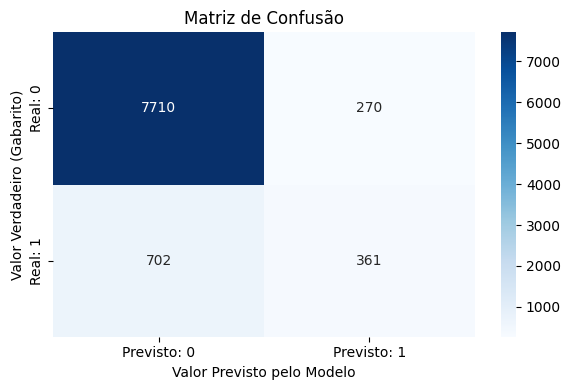

In [85]:
modelo = RandomForestClassifier(n_estimators=50, max_depth=None, random_state=42)

modelo.fit(X_train,y_train)

Y_predict = modelo.predict(X_test)

accuracy = accuracy_score(y_test,Y_predict)
print(f'A acurácia do modelo Random Forest foi de {accuracy*100:.2f}%')

matriz_c = confusion_matrix(y_test,Y_predict)
#print(matriz_c)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()